In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import random
import torchvision
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

img_shape = (1, 28, 28)
batch_size = 64
num_classes = 10

lr = 1e-4
beta1 = 0.0
alpha = 0.1
epochs = 10

Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
val_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


In [ ]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

In [ ]:
class JEMClassifier(nn.Module):
    def __init__(self, hidden_features=32):
        super().__init__()

        c_hid1 = hidden_features // 2
        c_hid2 = hidden_features
        c_hid3 = hidden_features * 2

        self.cnn_layers = nn.Sequential(
            nn.Conv2d(1, c_hid1, kernel_size=5, stride=2, padding=4),
            Swish(),
            nn.Conv2d(c_hid1, c_hid2, kernel_size=3, stride=2, padding=1),
            Swish(),
            nn.Conv2d(c_hid2, c_hid3, kernel_size=3, stride=2, padding=1),
            Swish(),
            nn.Conv2d(c_hid3, c_hid3, kernel_size=3, stride=2, padding=1),
            Swish(),
            nn.Flatten()
        )

        self.fc_energy = nn.Linear(c_hid3 * 4, 1)
        self.fc_class = nn.Linear(c_hid3 * 4, num_classes)

    def forward(self, x):
        features = self.cnn_layers(x)
        energy = self.fc_energy(features).squeeze(-1)
        logits = self.fc_class(features)
        return energy, logits

In [ ]:
class Sampler:

    def __init__(self, model, img_shape, sample_size, max_len=8192):
        self.model = model
        self.img_shape = img_shape
        self.sample_size = sample_size
        self.max_len = max_len
        self.examples = [(torch.rand((1,)+img_shape)*2-1) for _ in range(self.sample_size)]

    def sample_new_exmps(self, steps=60, step_size=10):

        device = next(self.model.parameters()).device

        n_new = np.random.binomial(self.sample_size, 0.05)
        rand_imgs = torch.rand((n_new,) + self.img_shape, device=device) * 2 - 1
        old_imgs = torch.cat(random.choices(self.examples, k=self.sample_size - n_new), dim=0).to(device)
        inp_imgs = torch.cat([rand_imgs, old_imgs], dim=0).detach()

        inp_imgs = Sampler.generate_samples(self.model, inp_imgs, steps=steps, step_size=step_size)

        self.examples = list(inp_imgs.cpu().chunk(self.sample_size, dim=0)) + self.examples
        self.examples = self.examples[:self.max_len]

        return inp_imgs

    @staticmethod
    def generate_samples(model, inp_imgs, steps=60, step_size=10):

        device = inp_imgs.device
        model.eval()

        for p in model.parameters():
            p.requires_grad = False

        inp_imgs.requires_grad = True

        for _ in range(steps):

            noise = torch.randn_like(inp_imgs) * 0.005
            inp_imgs.data.add_(noise)
            inp_imgs.data.clamp_(-1.0, 1.0)

            energy = -model(inp_imgs)[0]
            energy.sum().backward()

            inp_imgs.grad.data.clamp_(-0.03, 0.03)

            inp_imgs.data.add_(-step_size * inp_imgs.grad.data)
            inp_imgs.grad.zero_()
            inp_imgs.data.clamp_(-1.0, 1.0)

        for p in model.parameters():
            p.requires_grad = True

        model.train()

        return inp_imgs.detach()

In [ ]:
model = JEMClassifier(hidden_features=32).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr, betas=(beta1, 0.999))
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.97)

sampler = Sampler(model, img_shape=(1, 28, 28), sample_size=batch_size)

In [ ]:
def jem_loss(energy_real, energy_fake, logits, labels, alpha):

    min_batch_size = min(energy_real.size(0), energy_fake.size(0))
    energy_real = energy_real[:min_batch_size]
    energy_fake = energy_fake[:min_batch_size]

    reg_loss = alpha * (energy_real**2 + energy_fake**2).mean()
    cdiv_loss = energy_fake.mean() - energy_real.mean()
    class_loss = nn.CrossEntropyLoss()(logits, labels)

    total_loss = reg_loss + cdiv_loss + class_loss

    return total_loss, reg_loss, cdiv_loss, class_loss

In [ ]:
for epoch in range(epochs):

    model.train()

    train_loss = 0

    for real_imgs, labels in train_loader:

        real_imgs, labels = real_imgs.to(device), labels.to(device)

        real_imgs = real_imgs + torch.randn_like(real_imgs) * 0.005
        real_imgs = real_imgs.clamp(-1.0, 1.0)

        fake_imgs = sampler.sample_new_exmps(steps=60, step_size=10)

        energy_real, logits_real = model(real_imgs)
        energy_fake, _ = model(fake_imgs)

        loss, _, _, _ = jem_loss(energy_real, energy_fake, logits_real, labels, alpha)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.0490
Epoch 2, Loss: 0.4861
Epoch 3, Loss: 0.3554
Epoch 4, Loss: 0.2773
Epoch 5, Loss: 0.2185
Epoch 6, Loss: 0.1799
Epoch 7, Loss: 0.1531
Epoch 8, Loss: 0.1351
Epoch 9, Loss: 0.1221
Epoch 10, Loss: 0.1115


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        _, logits = model(imgs)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.9734


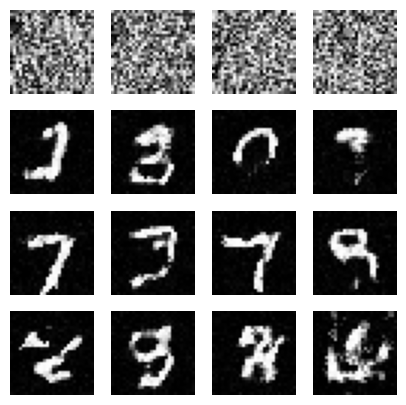

In [ ]:
def generate_images(model, sampler, num_images=16):

    imgs = sampler.sample_new_exmps(steps=200, step_size=0.1)
    imgs = imgs[:num_images].cpu()

    imgs = (imgs + 1) / 2

    fig, axes = plt.subplots(4, 4, figsize=(5,5))

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap="gray")
        ax.axis("off")

    plt.show()

generate_images(model, sampler)